# Chapter 11 Exercises

These exercises turn the Chapter 11 CNN ideas into small Fashion-MNIST comparisons.
The focus is on how activation choice, extra convolution depth, and different downsampling strategies change shapes and validation accuracy.

## Setup

In [1]:
# !pip -q install torch torchvision matplotlib
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset

plt.style.use('seaborn-v0_8')
%config InlineBackend.figure_format = 'retina'

try:
    from torchvision import datasets, transforms
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'torchvision is required for this notebook. Install the repository environment before running it.'
    ) from exc


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TRAIN_SAMPLES = 4000
VAL_SAMPLES = 1000
TEST_SAMPLES = 1000
BATCH_SIZE = 128
EPOCHS = 3
LEARNING_RATE = 1e-3


def make_fashion_mnist_loaders(train_size=TRAIN_SAMPLES, val_size=VAL_SAMPLES, test_size=TEST_SAMPLES, batch_size=BATCH_SIZE, seed=42):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.2860,), (0.3530,)),
    ])

    try:
        train_full = datasets.FashionMNIST(root='data', train=True, download=True, transform=transform)
        test_full = datasets.FashionMNIST(root='data', train=False, download=True, transform=transform)
    except Exception as exc:
        raise RuntimeError(
            'Could not load Fashion-MNIST. If the download fails, rerun when internet access is available or place the dataset under ./data.'
        ) from exc

    generator = torch.Generator().manual_seed(seed)
    train_perm = torch.randperm(len(train_full), generator=generator)
    test_perm = torch.randperm(len(test_full), generator=generator)

    train_idx = train_perm[:train_size]
    val_idx = train_perm[train_size:train_size + val_size]
    test_idx = test_perm[:test_size]

    train_ds = Subset(train_full, train_idx.tolist())
    val_ds = Subset(train_full, val_idx.tolist())
    test_ds = Subset(test_full, test_idx.tolist())

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


class ExerciseCNN(nn.Module):
    def __init__(self, activation='relu', third_block=False, downsample='pool'):
        super().__init__()
        act_cls = nn.ReLU if activation == 'relu' else nn.Tanh
        channels = [16, 32] + ([32] if third_block else [])

        layers = []
        in_channels = 1
        for out_channels in channels:
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            layers.append(act_cls())
            if downsample == 'pool':
                layers.append(nn.MaxPool2d(2))
            elif downsample == 'stride':
                layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=2, padding=1))
                layers.append(act_cls())
            else:
                raise ValueError("downsample must be 'pool' or 'stride'")
            in_channels = out_channels

        self.features = nn.Sequential(*layers)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            feature_dim = self.features(dummy).view(1, -1).shape[1]
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(feature_dim, 10))

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        train_loss = running_loss / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        print(f'epoch {epoch:02d} | train loss {train_loss:.4f} | val acc {val_acc:.3f}')

    return history


def run_experiment(configs, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE):
    results = {}
    for name, model in configs.items():
        print(f"\n{name}")
        history = train_model(model, train_loader, val_loader, epochs=epochs, lr=lr)
        results[name] = {
            'history': history,
            'params': count_parameters(model),
            'best_val_acc': max(history['val_acc']),
            'final_train_loss': history['train_loss'][-1],
        }
    return results


def trace_shapes(model, input_shape=(1, 1, 28, 28)):
    x = torch.zeros(input_shape)
    shapes = [('input', tuple(x.shape))]
    for idx, layer in enumerate(model.features):
        x = layer(x)
        layer_name = f'{layer.__class__.__name__}_{idx}'
        shapes.append((layer_name, tuple(x.shape)))
    x = model.classifier[0](x)
    shapes.append(('flatten', tuple(x.shape)))
    x = model.classifier[1](x)
    shapes.append(('logits', tuple(x.shape)))
    return shapes


train_loader, val_loader, test_loader = make_fashion_mnist_loaders()
xb, yb = next(iter(train_loader))
print('Device:', device)
print('Train subset:', len(train_loader.dataset))
print('Validation subset:', len(val_loader.dataset))
print('Test subset:', len(test_loader.dataset))
print('Mini-batch shape:', tuple(xb.shape), tuple(yb.shape))

Device: cpu
Train subset: 4000
Validation subset: 1000
Test subset: 1000
Mini-batch shape: (128, 1, 28, 28) (128,)


## Exercise 1

Replace `ReLU` with `Tanh` in the same two-block CNN.
Train both versions on the same Fashion-MNIST subset and compare the loss curve and validation accuracy.


ReLU CNN


epoch 01 | train loss 1.3394 | val acc 0.690


epoch 02 | train loss 0.7021 | val acc 0.732


epoch 03 | train loss 0.5920 | val acc 0.782

Tanh CNN


epoch 01 | train loss 1.2096 | val acc 0.733


epoch 02 | train loss 0.6586 | val acc 0.771


epoch 03 | train loss 0.5588 | val acc 0.816


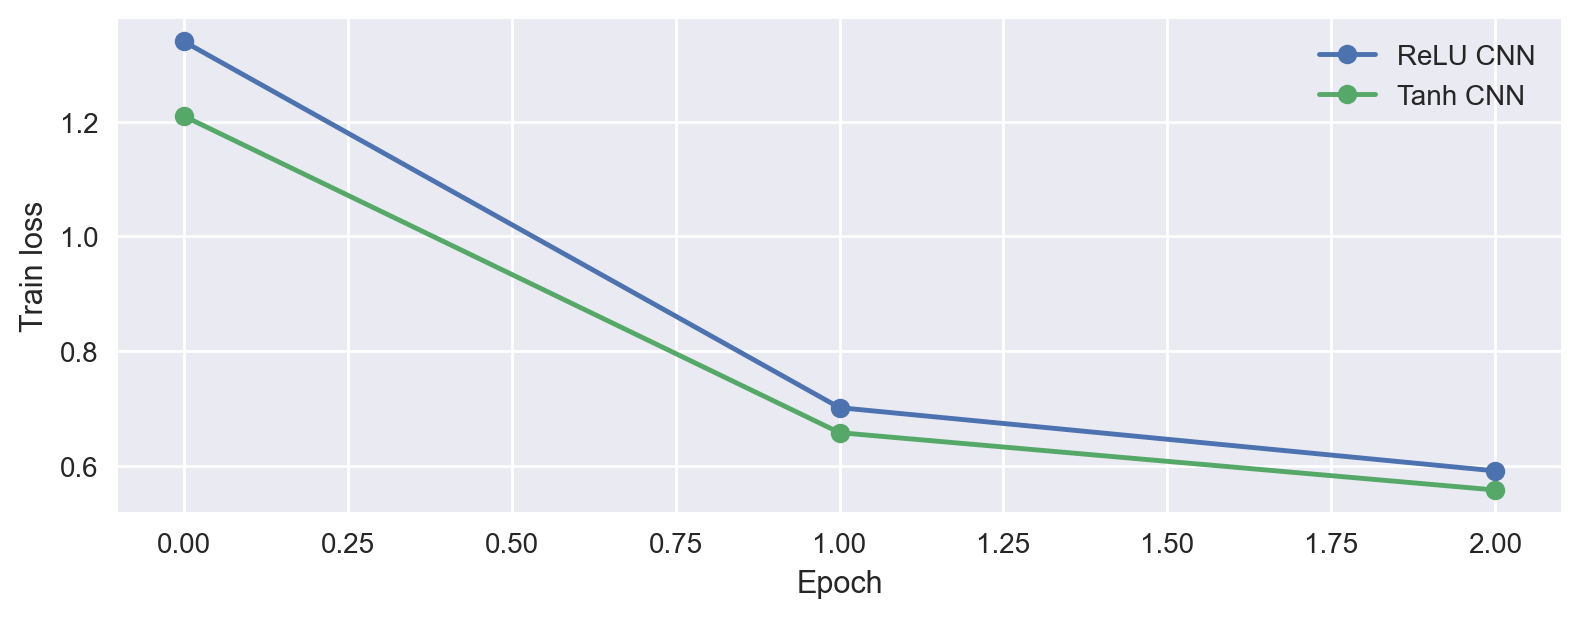

ReLU CNN  | final train loss = 0.5920 | best val acc = 0.782
Tanh CNN  | final train loss = 0.5588 | best val acc = 0.816
Takeaway: On this small run, Tanh was competitive, but compare the slower loss dynamics carefully.


In [2]:
set_seed(42)
exercise1 = run_experiment(
    {
        'ReLU CNN': ExerciseCNN(activation='relu', third_block=False, downsample='pool'),
        'Tanh CNN': ExerciseCNN(activation='tanh', third_block=False, downsample='pool'),
    },
    train_loader,
    val_loader,
)

plt.figure(figsize=(8, 3.2))
for name, record in exercise1.items():
    plt.plot(record['history']['train_loss'], marker='o', label=name)
plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

for name, record in exercise1.items():
    print(
        f"{name:9s} | final train loss = {record['final_train_loss']:.4f} | "
        f"best val acc = {record['best_val_acc']:.3f}"
    )

relu_acc = exercise1['ReLU CNN']['best_val_acc']
tanh_acc = exercise1['Tanh CNN']['best_val_acc']
if relu_acc >= tanh_acc:
    print('Takeaway: On this small run, ReLU trained a bit more easily than Tanh.')
else:
    print('Takeaway: On this small run, Tanh was competitive, but compare the slower loss dynamics carefully.')

## Exercise 2

Add a third convolution block with 32 channels.
Compare the original two-block CNN with the deeper three-block version using the same optimizer and number of epochs.

In [3]:
set_seed(42)
exercise2 = run_experiment(
    {
        '2 blocks': ExerciseCNN(activation='relu', third_block=False, downsample='pool'),
        '3 blocks': ExerciseCNN(activation='relu', third_block=True, downsample='pool'),
    },
    train_loader,
    val_loader,
)

for name, record in exercise2.items():
    print(
        f"{name:8s} | parameters = {record['params']:6d} | "
        f"best val acc = {record['best_val_acc']:.3f}"
    )

acc_two = exercise2['2 blocks']['best_val_acc']
acc_three = exercise2['3 blocks']['best_val_acc']
if acc_three >= acc_two:
    print('Takeaway: The extra conv block helped a little on this subset, but the gain should be judged against the added parameters.')
else:
    print('Takeaway: More depth did not help automatically here; the third block added complexity without a clear validation win.')


2 blocks


epoch 01 | train loss 1.3428 | val acc 0.717


epoch 02 | train loss 0.6981 | val acc 0.770


epoch 03 | train loss 0.5835 | val acc 0.787

3 blocks


epoch 01 | train loss 1.6820 | val acc 0.669


epoch 02 | train loss 0.8995 | val acc 0.728


epoch 03 | train loss 0.7289 | val acc 0.740
2 blocks | parameters =  20490 | best val acc = 0.787
3 blocks | parameters =  16938 | best val acc = 0.740
Takeaway: More depth did not help automatically here; the third block added complexity without a clear validation win.


## Exercise 3

Replace `MaxPool2d(2)` with a stride-2 convolution.
Compare the tensor shapes of both models and then compare their validation accuracy on the same data.

In [4]:
maxpool_model = ExerciseCNN(activation='relu', third_block=False, downsample='pool')
stride_model = ExerciseCNN(activation='relu', third_block=False, downsample='stride')

print('Shape trace: MaxPool model')
for name, shape in trace_shapes(maxpool_model):
    print(f'  {name:16s} {shape}')

print('\nShape trace: Stride-conv model')
for name, shape in trace_shapes(stride_model):
    print(f'  {name:16s} {shape}')

set_seed(42)
exercise3 = run_experiment(
    {
        'MaxPool CNN': maxpool_model,
        'Stride CNN': stride_model,
    },
    train_loader,
    val_loader,
)

for name, record in exercise3.items():
    print(
        f"{name:11s} | parameters = {record['params']:6d} | "
        f"best val acc = {record['best_val_acc']:.3f}"
    )

pool_acc = exercise3['MaxPool CNN']['best_val_acc']
stride_acc = exercise3['Stride CNN']['best_val_acc']
if stride_acc >= pool_acc:
    print('Takeaway: Learned stride-2 downsampling was competitive here, and it changes the shape path by replacing pooling with trainable layers.')
else:
    print('Takeaway: Max pooling stayed a bit stronger on this run, even though both models reduced the spatial size in a similar way.')

Shape trace: MaxPool model
  input            (1, 1, 28, 28)
  Conv2d_0         (1, 16, 28, 28)
  ReLU_1           (1, 16, 28, 28)
  MaxPool2d_2      (1, 16, 14, 14)
  Conv2d_3         (1, 32, 14, 14)
  ReLU_4           (1, 32, 14, 14)
  MaxPool2d_5      (1, 32, 7, 7)
  flatten          (1, 1568)
  logits           (1, 10)

Shape trace: Stride-conv model
  input            (1, 1, 28, 28)
  Conv2d_0         (1, 16, 28, 28)
  ReLU_1           (1, 16, 28, 28)
  Conv2d_2         (1, 16, 14, 14)
  ReLU_3           (1, 16, 14, 14)
  Conv2d_4         (1, 32, 14, 14)
  ReLU_5           (1, 32, 14, 14)
  Conv2d_6         (1, 32, 7, 7)
  ReLU_7           (1, 32, 7, 7)
  flatten          (1, 1568)
  logits           (1, 10)

MaxPool CNN


epoch 01 | train loss 1.2822 | val acc 0.692


epoch 02 | train loss 0.7097 | val acc 0.755


epoch 03 | train loss 0.5882 | val acc 0.797

Stride CNN


epoch 01 | train loss 1.4619 | val acc 0.713


epoch 02 | train loss 0.7150 | val acc 0.760


epoch 03 | train loss 0.5998 | val acc 0.801
MaxPool CNN | parameters =  20490 | best val acc = 0.797
Stride CNN  | parameters =  32058 | best val acc = 0.801
Takeaway: Learned stride-2 downsampling was competitive here, and it changes the shape path by replacing pooling with trainable layers.


## Summary

- Replacing `ReLU` with `Tanh` changes optimization behavior, not just the activation formula.
- Adding depth can improve a CNN, but the gain has to justify the extra parameters.
- Replacing pooling with stride-2 convolutions changes both the tensor path and the learnable capacity of the model.
- On Fashion-MNIST, small CNN design choices are easy to test with short controlled runs.